In [5]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/citrus01.csv")
df

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
...,...,...,...,...,...,...
9995,grapefruit,15.35,253.89,149,77,20
9996,grapefruit,15.41,254.67,148,68,7
9997,grapefruit,15.59,256.50,168,82,20
9998,grapefruit,15.92,260.14,142,72,11


In [6]:
df.columns

Index(['name', 'diameter', 'weight', 'red', 'green', 'blue'], dtype='object')

In [7]:
t1 = {'name':'종류', 'diameter':'지름', 'weight':'무게', 'red':'빨강', 'green':'초록', 'blue':'파랑'}
df.rename(columns=t1, inplace=True)
df

,종류,지름,무게,빨강,초록,파랑
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
...,...,...,...,...,...,...
9995,grapefruit,15.35,253.89,149,77,20
9996,grapefruit,15.41,254.67,148,68,7
9997,grapefruit,15.59,256.50,168,82,20
9998,grapefruit,15.92,260.14,142,72,11


In [8]:
df['종류'] = df['종류'].map({'orange':0, 'grapefruit':1})
df.dtypes

종류      int64
지름    float64
무게    float64
빨강      int64
초록      int64
파랑      int64
dtype: object

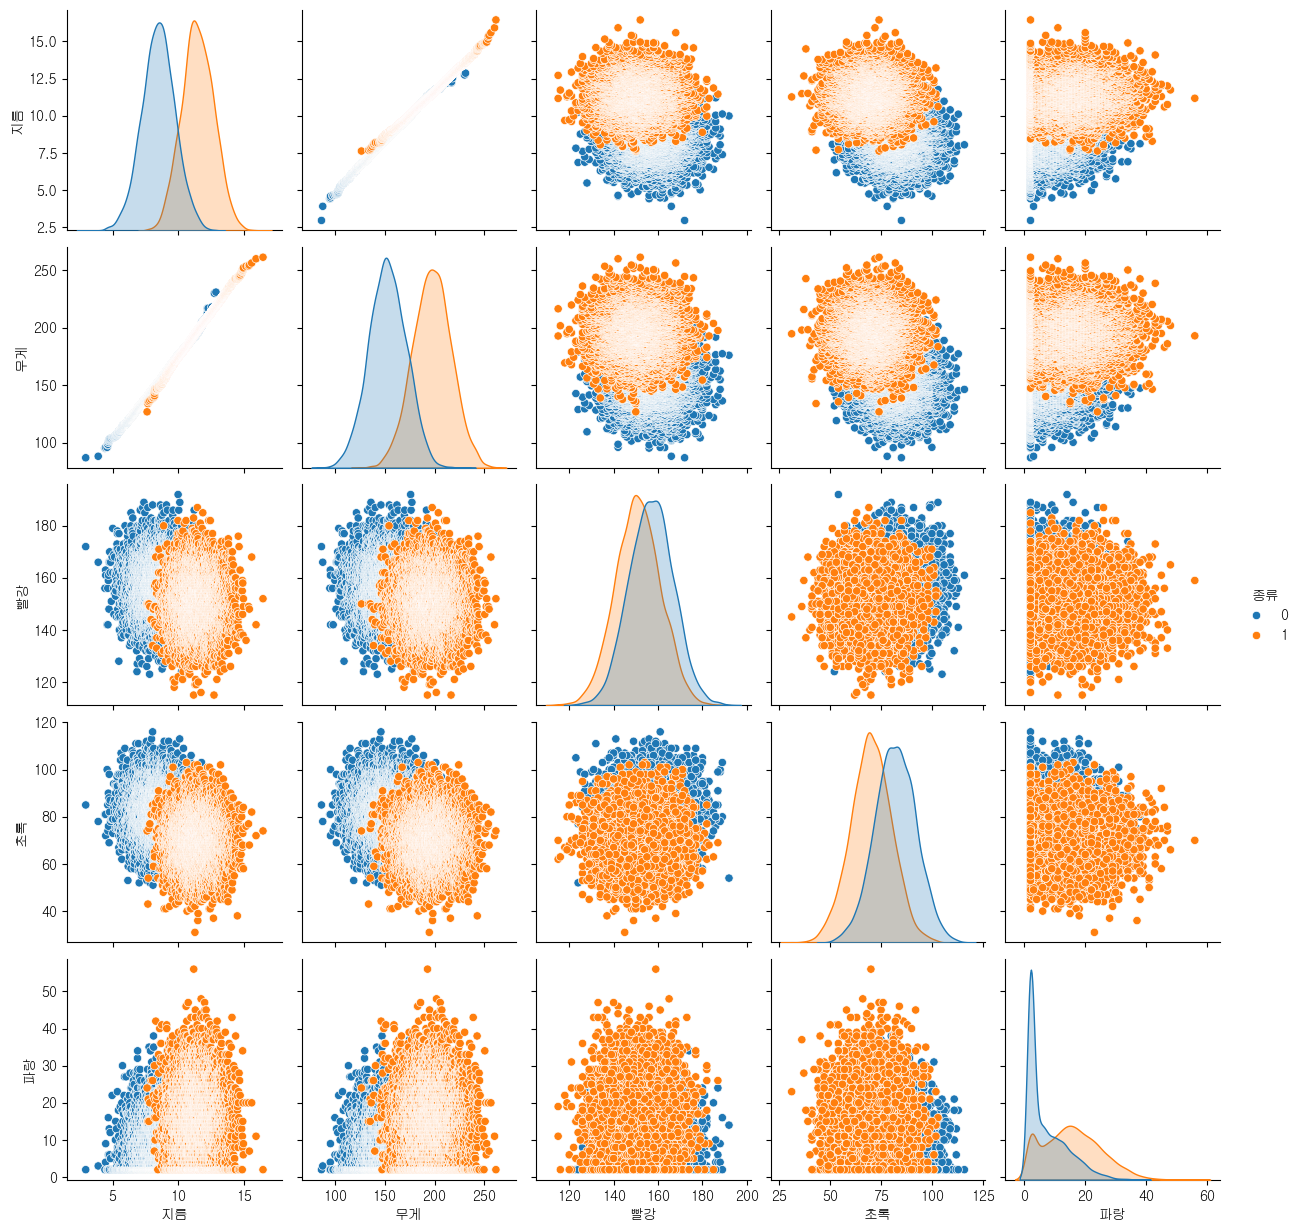

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc('font', family='Gulim')

sns.pairplot(data=df, hue='종류')
plt.show()

In [10]:
x = df[['지름','무게','빨강','초록','파랑']].values
y = df['종류'].values
x.shape, y.shape

((10000, 5), (10000,))

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000, 5), (2000, 5), (8000,), (2000,))

In [13]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)
model.score(x_train, y_train), model.score(x_test, y_test)

(1.0, 0.958)